# Baseline supervised classifier (#58)

Trains and validates a baseline supervised model on **normalized sensor
features + patient metadata**, per issue #58.

## Scope & honesty note

- Sensor features come from the real 20 reference measurements via
  `src/features.py` (AUC, delta, response time, slope, ...).
- **Patient metadata is synthetic** — the real labelled clinical dataset (with
  age / sex / comorbidities) has not been provided yet. We generate plausible
  metadata to demonstrate the required capability from the issue's *Crucial PM
  Insight*: the pipeline must accept and process metadata alongside sensor
  curves. The metadata values here are illustrative, not real patients.
- Target for this demo is the substance **group** (oil / ice-based / other),
  since there is ~1 example per individual substance. The pipeline is identical
  for the real clinical target once data arrives.


## 1. Sensor features (real) + patient metadata (synthetic)

In [ ]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

sys.path.insert(0, "../src")
from features import measurement_features

rng = np.random.default_rng(42)
DATA_DIR = "/mnt/user-data/uploads"  # local reference files (not in repo)


def group_of(stem):
    s = stem.lower()
    if s.startswith("лед") or s.startswith("лёд"):
        return "ice-based"
    if s.startswith("масло"):
        return "oil"
    return "other"


files = sorted(Path(DATA_DIR).glob("*.XML"))
rows, labels = [], []
for f in files:
    feats = measurement_features(f)
    numeric = {k: v for k, v in feats.items() if isinstance(v, (int, float))}
    rows.append(numeric)
    labels.append(group_of(f.stem))

X_sensor = pd.DataFrame(rows).fillna(0.0)

# SYNTHETIC patient metadata (not real)
n = len(files)
meta = pd.DataFrame(
    {
        "age": rng.integers(18, 80, size=n),
        "sex": rng.choice(["M", "F"], size=n),
        "comorbidity": rng.choice(["none", "diabetes", "hypertension"], size=n),
    }
)
meta_encoded = pd.get_dummies(meta, columns=["sex", "comorbidity"]).astype(float)
meta_encoded.columns = [f"meta_{c}" for c in meta_encoded.columns]

X = pd.concat(
    [X_sensor.reset_index(drop=True), meta_encoded.reset_index(drop=True)], axis=1
)
y = np.array(labels)

print(
    f"sensor features: {X_sensor.shape[1]}, metadata features: {meta_encoded.shape[1]}"
)
print(f"combined feature matrix: {X.shape}")
print("classes:", Counter(y))
print("\nmetadata sample (synthetic):")
print(meta.head())

sensor features: 64, metadata features: 6
combined feature matrix: (20, 70)
classes: Counter({np.str_('oil'): 13, np.str_('ice-based'): 4, np.str_('other'): 3})

metadata sample (synthetic):
   age sex   comorbidity
0   23   F          none
1   65   M  hypertension
2   58   M  hypertension
3   45   F      diabetes
4   44   F          none


## 2. Train baseline classifier (Random Forest)\n\nFast-executing baseline model on the combined sensor + metadata features.

In [2]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

clf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=200, random_state=42),
)

t0 = time.perf_counter()
clf.fit(X, y)
elapsed = (time.perf_counter() - t0) * 1000
print(f"trained on {X.shape[1]} features (sensor + metadata) in {elapsed:.0f} ms")
print("training accuracy:", clf.score(X, y))

trained on 70 features (sensor + metadata) in 205 ms
training accuracy: 1.0


## 3. Validation metrics — Precision / Recall / F1 / Confusion Matrix\n\nLeave-one-out cross-validation (honest estimate for a small dataset).

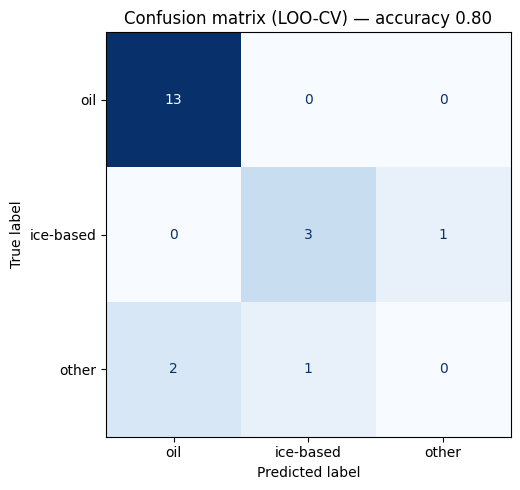

              precision    recall  f1-score   support

         oil       0.87      1.00      0.93        13
   ice-based       0.75      0.75      0.75         4
       other       0.00      0.00      0.00         3

    accuracy                           0.80        20
   macro avg       0.54      0.58      0.56        20
weighted avg       0.71      0.80      0.75        20



In [3]:
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
)
import matplotlib.pyplot as plt

y_pred = cross_val_predict(clf, X, y, cv=LeaveOneOut())

order = ["oil", "ice-based", "other"]
cm = confusion_matrix(y, y_pred, labels=order)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=order).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Confusion matrix (LOO-CV) — accuracy {accuracy_score(y, y_pred):.2f}")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred, labels=order, zero_division=0))

## 4. Feature importance — do metadata features contribute?\n\nShows the model actually uses the metadata inputs alongside sensor features.

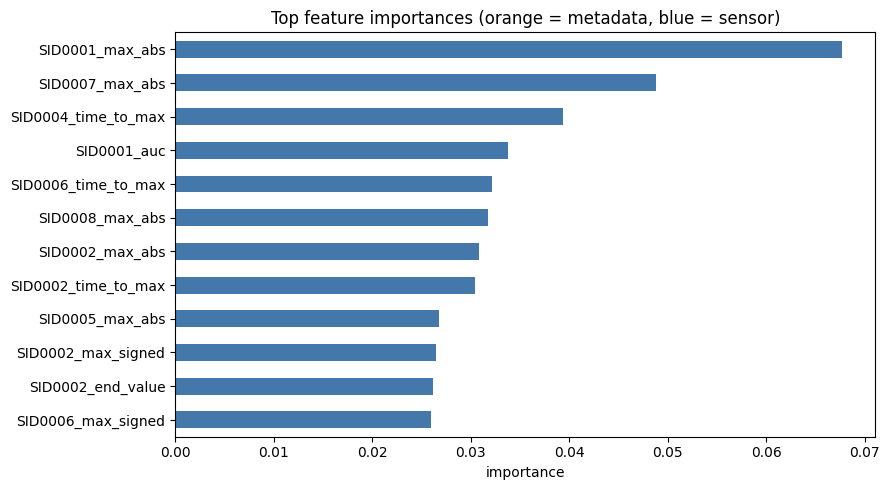

In [4]:
rf = clf.named_steps["randomforestclassifier"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

top = imp.head(12)
is_meta = [c.startswith("meta_") for c in top.index]
colors = ["#e8833a" if m else "#4477aa" for m in is_meta]

fig, ax = plt.subplots(figsize=(9, 5))
top[::-1].plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Top feature importances (orange = metadata, blue = sensor)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 5. Predict a single measurement

In [5]:
example_idx = -3  # e.g. масло_шалфея
x_one = X.iloc[[example_idx]]
pred = clf.predict(x_one)[0]
proba = clf.predict_proba(x_one)[0]
classes = clf.named_steps["randomforestclassifier"].classes_
conf = dict(zip(classes, proba))

print(f"file       : {files[example_idx].stem}")
print(f"true group : {y[example_idx]}")
print(f"predicted  : {pred}  ({conf[pred]:.0%} confidence)")

file       : масло_шалфея
true group : oil
predicted  : oil  (92% confidence)
